## Solar Panel Detection using YOLOv8

This project focuses on detecting solar panels from aerial and rooftop imagery using the YOLOv8 object detection model.

The system is capable of:
- detecting solar panels
- drawing bounding boxes
- generating confidence scores
- validating predictions on unseen images

This project explores how Computer Vision can support renewable energy monitoring and smart infrastructure systems.

----------------------------------------------
#### INSTALLING DEPENDENCIES

In [2]:
!pip install ultralytics roboflow

  Using cached ultralytics-8.4.48-py3-none-any.whl.metadata (39 kB)
  Using cached roboflow-1.3.8-py3-none-any.whl.metadata (11 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     -------------------- ------------------- 30.7/61.0 kB ? eta -:--:--
     ------------------------------- ------ 51.2/61.0 kB 238.1 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 249.8 kB/s eta 0:00:00
  Using cached torch-2.11.0-cp312-cp312-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pi_heif-1.3.0-cp312-cp312-wi

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.39.0 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#installing pytorch libraries for yolov8 models
!pip install torch torchvision torchaudio8

ERROR: Could not find a version that satisfies the requirement torchaudio8 (from versions: none)
ERROR: No matching distribution found for torchaudio8

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#INSTALLING VARIOUS LIBRARIES
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import Image, display
import pandas as pd
import os


#### Dataset Exploration

Before training the model, I explored the dataset to understand:
- the number of solar systems
- panel distribution
- panel area
- household and geographical information

This helps provide insight into the data used for training and analysis

In [2]:
df = pd.read_csv("deepsolar_tract.csv", encoding='latin1')

In [3]:
#to display the first five rows of the dataset
df.head()

,Unnamed: 0,tile_count,solar_system_count,total_panel_area,fips,average_household_income,county,education_bachelor,education_college,education_doctoral,...,incentive_count_nonresidential,incentive_residential_state_level,incentive_nonresidential_state_level,net_metering,feedin_tariff,cooperate_tax,property_tax,sales_tax,rebate,avg_electricity_retail_rate
0,0,0.0,0.0,0.000000,27145011200,70352.789869,Stearns County,569,1690,13,...,39,11,13,34,0,0,25,12,0,9.46
1,1,25.0,21.0,1133.436461,27145011301,61727.085202,Stearns County,674,1434,108,...,39,11,13,34,0,0,25,12,0,9.46
2,2,3.0,3.0,64.505776,27145011302,71496.886583,Stearns County,854,1459,31,...,39,11,13,34,0,0,25,12,0,9.46
3,3,0.0,0.0,0.000000,27145011304,86840.152755,Stearns County,640,1116,68,...,39,11,13,34,0,0,25,12,0,9.46
4,4,5.0,5.0,164.583303,27145011400,89135.315597,Stearns County,654,1314,15,...,39,11,13,34,0,0,25,12,0,9.46


In [4]:
#checking the dimensionality of the dataset
df.shape

(72537, 169)

#### Downloading datasets from RoboFlow

In [5]:
#connecting to the roboflow workspace and dataset
rf = Roboflow(api_key="1oloKpPl6PWGjQxzqHgS")

project = rf.workspace("1-zcs37").project("solar-panel-exbow")

version = project.version(1)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


### Train YOLOv8 Model


##### Model Training

In this stage, I trained a YOLOv8 model on solar panel imagery.

The model learns:
- solar panel shapes
- object boundaries
- spatial features
- rooftop patterns

The goal is to enable accurate solar panel detection on unseen images.

In [6]:
#training the YOLOv8 Model
model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=5,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.48  Python-3.12.4 torch-2.11.0+cpu CPU (Intel Core i7-7600U 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\Zione\Downloads\solar_panel_detection_project\solar-panel-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=Fals

#### VALIDATION RESULTS

##### Validation Predictions

The images below show validation predictions generated during training.

Bounding boxes represent detected solar panels along with confidence scores.

In [21]:
metrics = model.val()

Ultralytics 8.4.48  Python-3.12.4 torch-2.11.0+cpu CPU (Intel Core i7-7600U 2.80GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 99.249.6 MB/s, size: 86.4 KB)
val: Scanning C:\Users\Zione\Downloads\solar_panel_detection_project\solar-panel-1\valid\labels.cache... 137 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.7s/it 33.3s4.0ss
                   all        137        436      0.613      0.189      0.196      0.108
                     0         36         55      0.355      0.618      0.585      0.398
                     1         20         74      0.994      0.027     0.0882     0.0464
                     2         38        181          1          0     0.0289    0.00669
                     3         15         29      0.104      0.069     0.0827     0.0333
      

In [ ]:
print(os.listdir(r'C:\Users\Zione\runs\detect\val'))

['BoxF1_curve.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg']


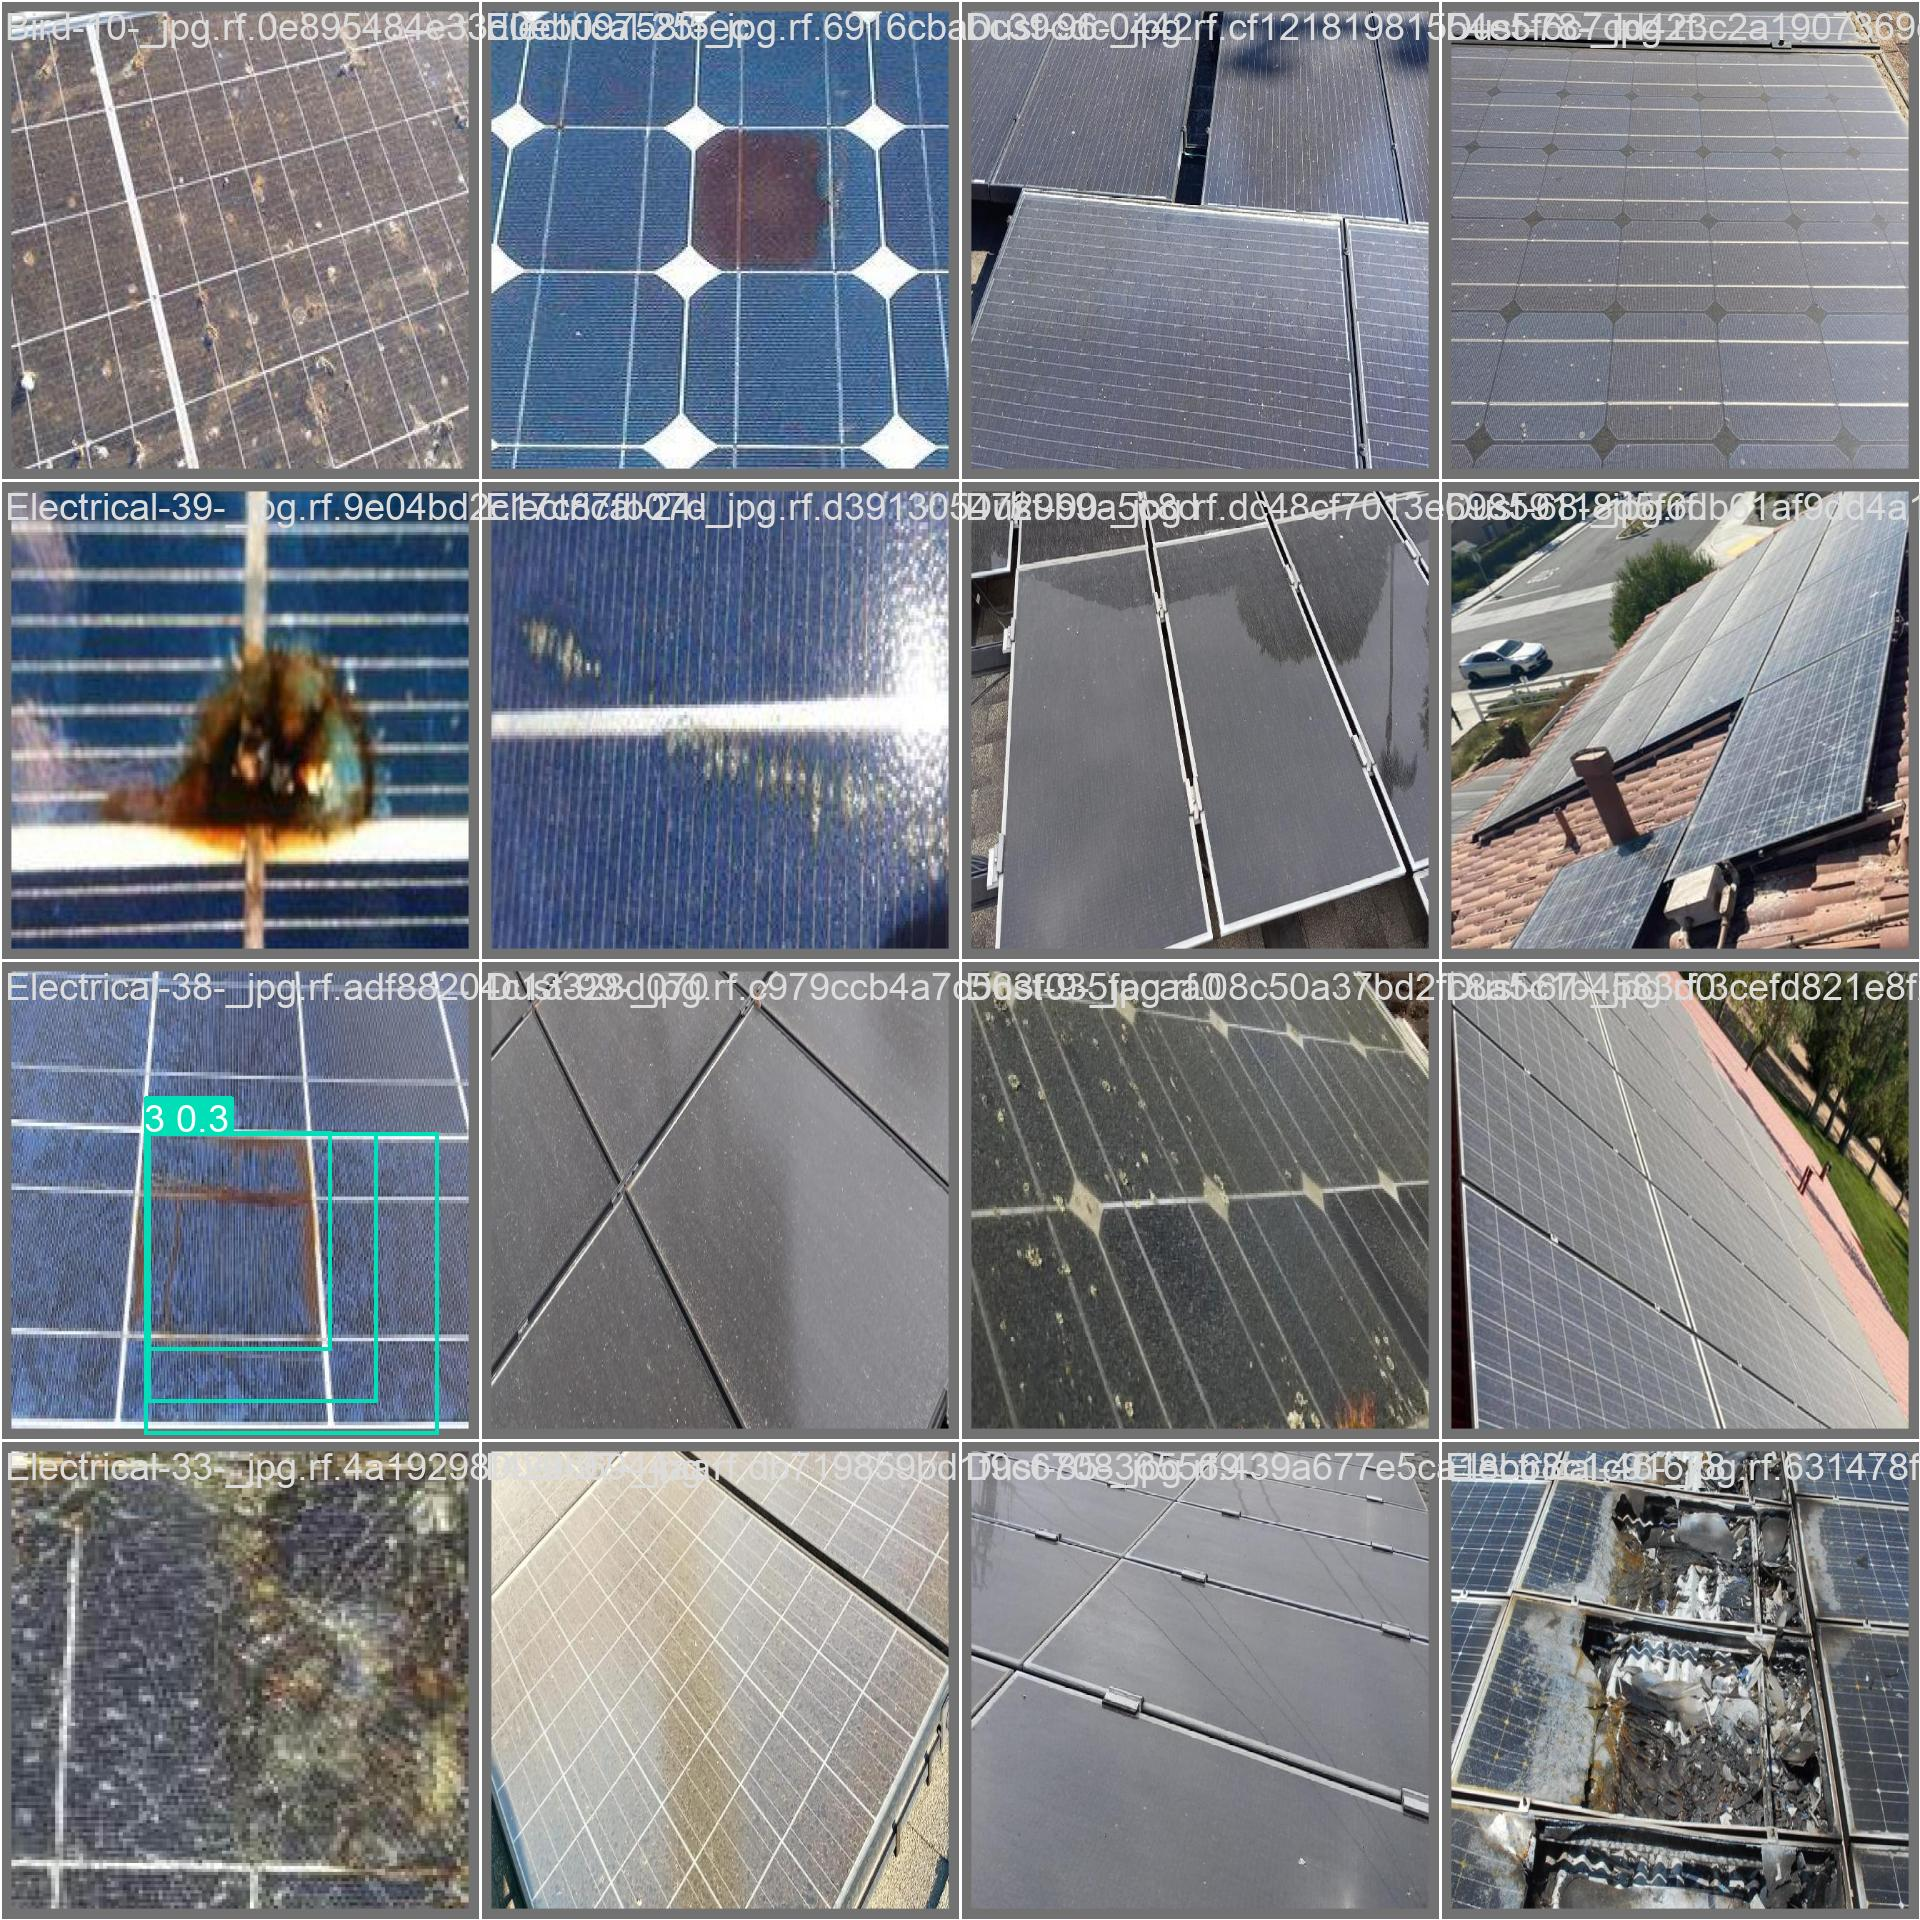

In [26]:
#Visualizing detection outputs
display(Image(filename=r'C:\Users\Zione\runs\detect\val\val_batch0_pred.jpg'))

In [22]:
import glob 
print(glob.glob('**/*.png', recursive=True))



[]


### ADVANCED MODEL EVALUATION

After training the YOLOv8 model, i evaluated its performance using different computer vison evaluation metrics generated during training. These metrics help measure how accurately  the model detects solar panels across validation images and different rooftop conditions.

##### Confusion Matrix 
The confusion matrix helped me understand how well the model distinguished solar panels from background objects and background structures during validation. It reveals the correct and incorrect predictions through visualization.

Displaying Confusion Matrix...


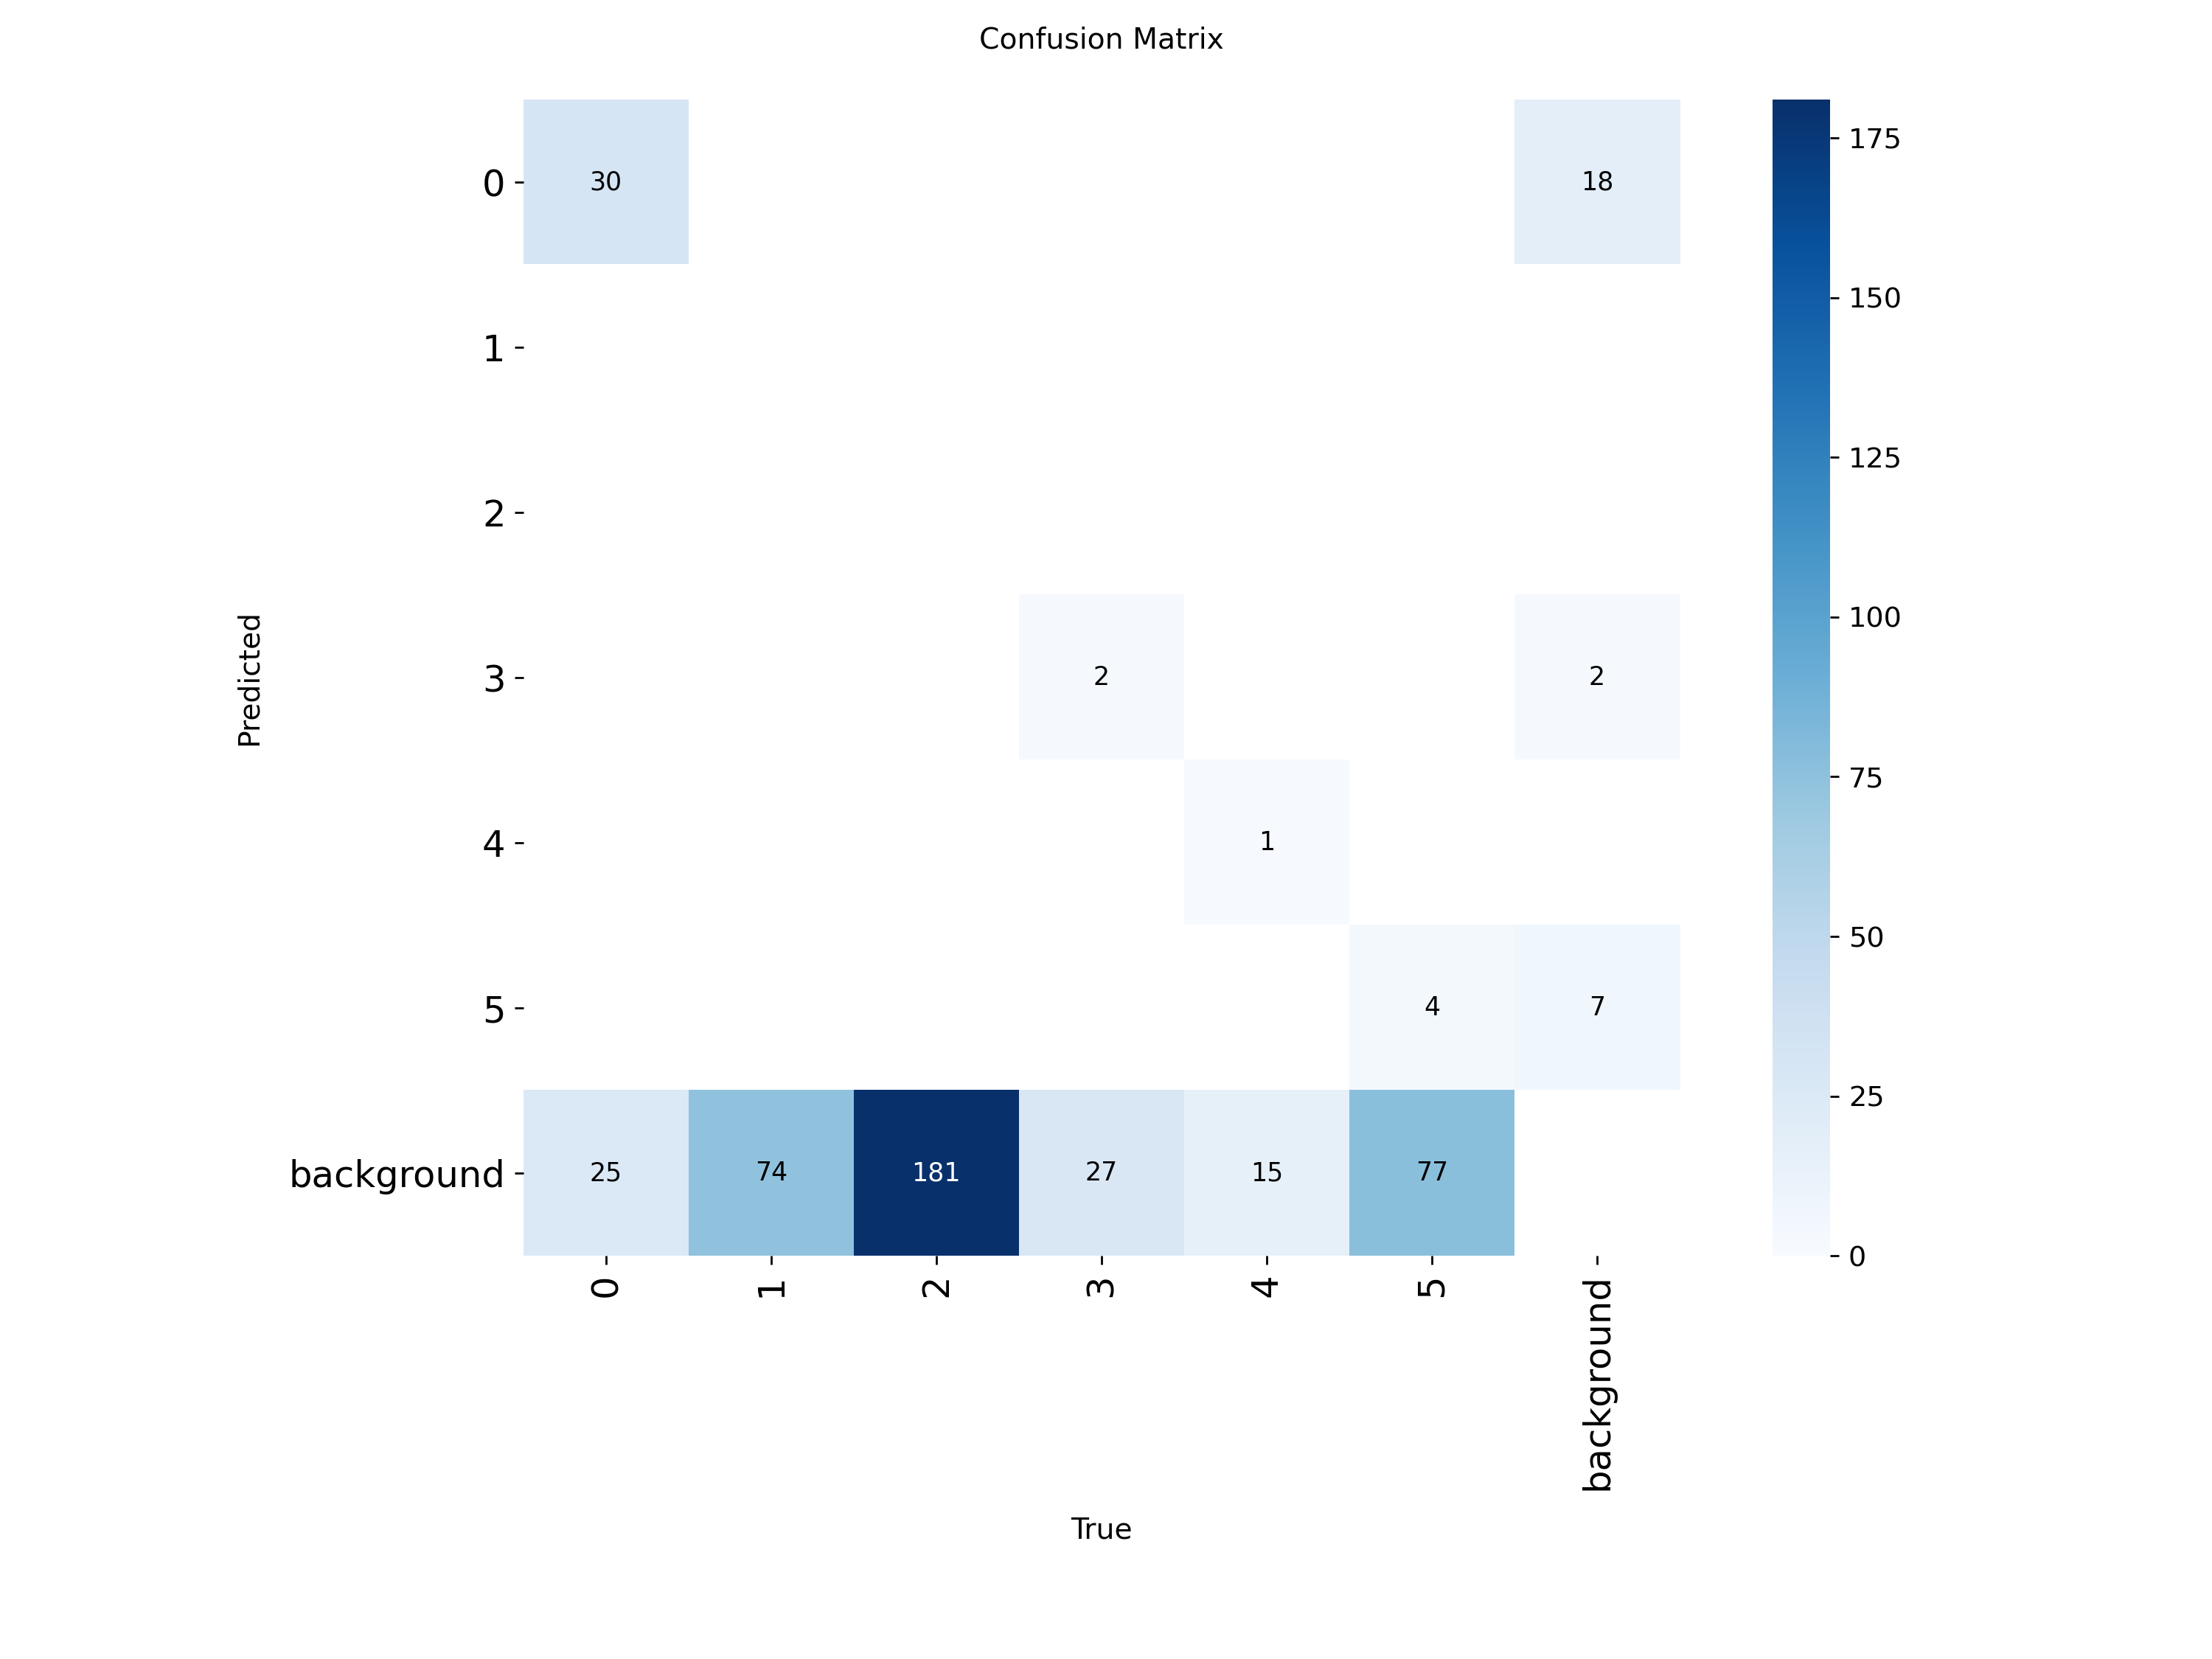

In [27]:
print("Displaying Confusion Matrix...")
display(Image(filename=r'C:\Users\Zione\runs\detect\val\confusion_matrix.png'))

#### Confusion Matrix Analysis
The confusion matrix was used to evaluate the perofrmance of the YOLOv8 model during Validation.
The results show that the model achieved good solar panel performance, with most predictions correctly classified. Some minor class overlap and background confusion were obsered , highlighting areas for future improvement.

#### F1-Confidence Curve
The F1-Confidence curve helped evaluate the balance between precision  and recall at different confidence thresholds.

Displaying F1 Curve...


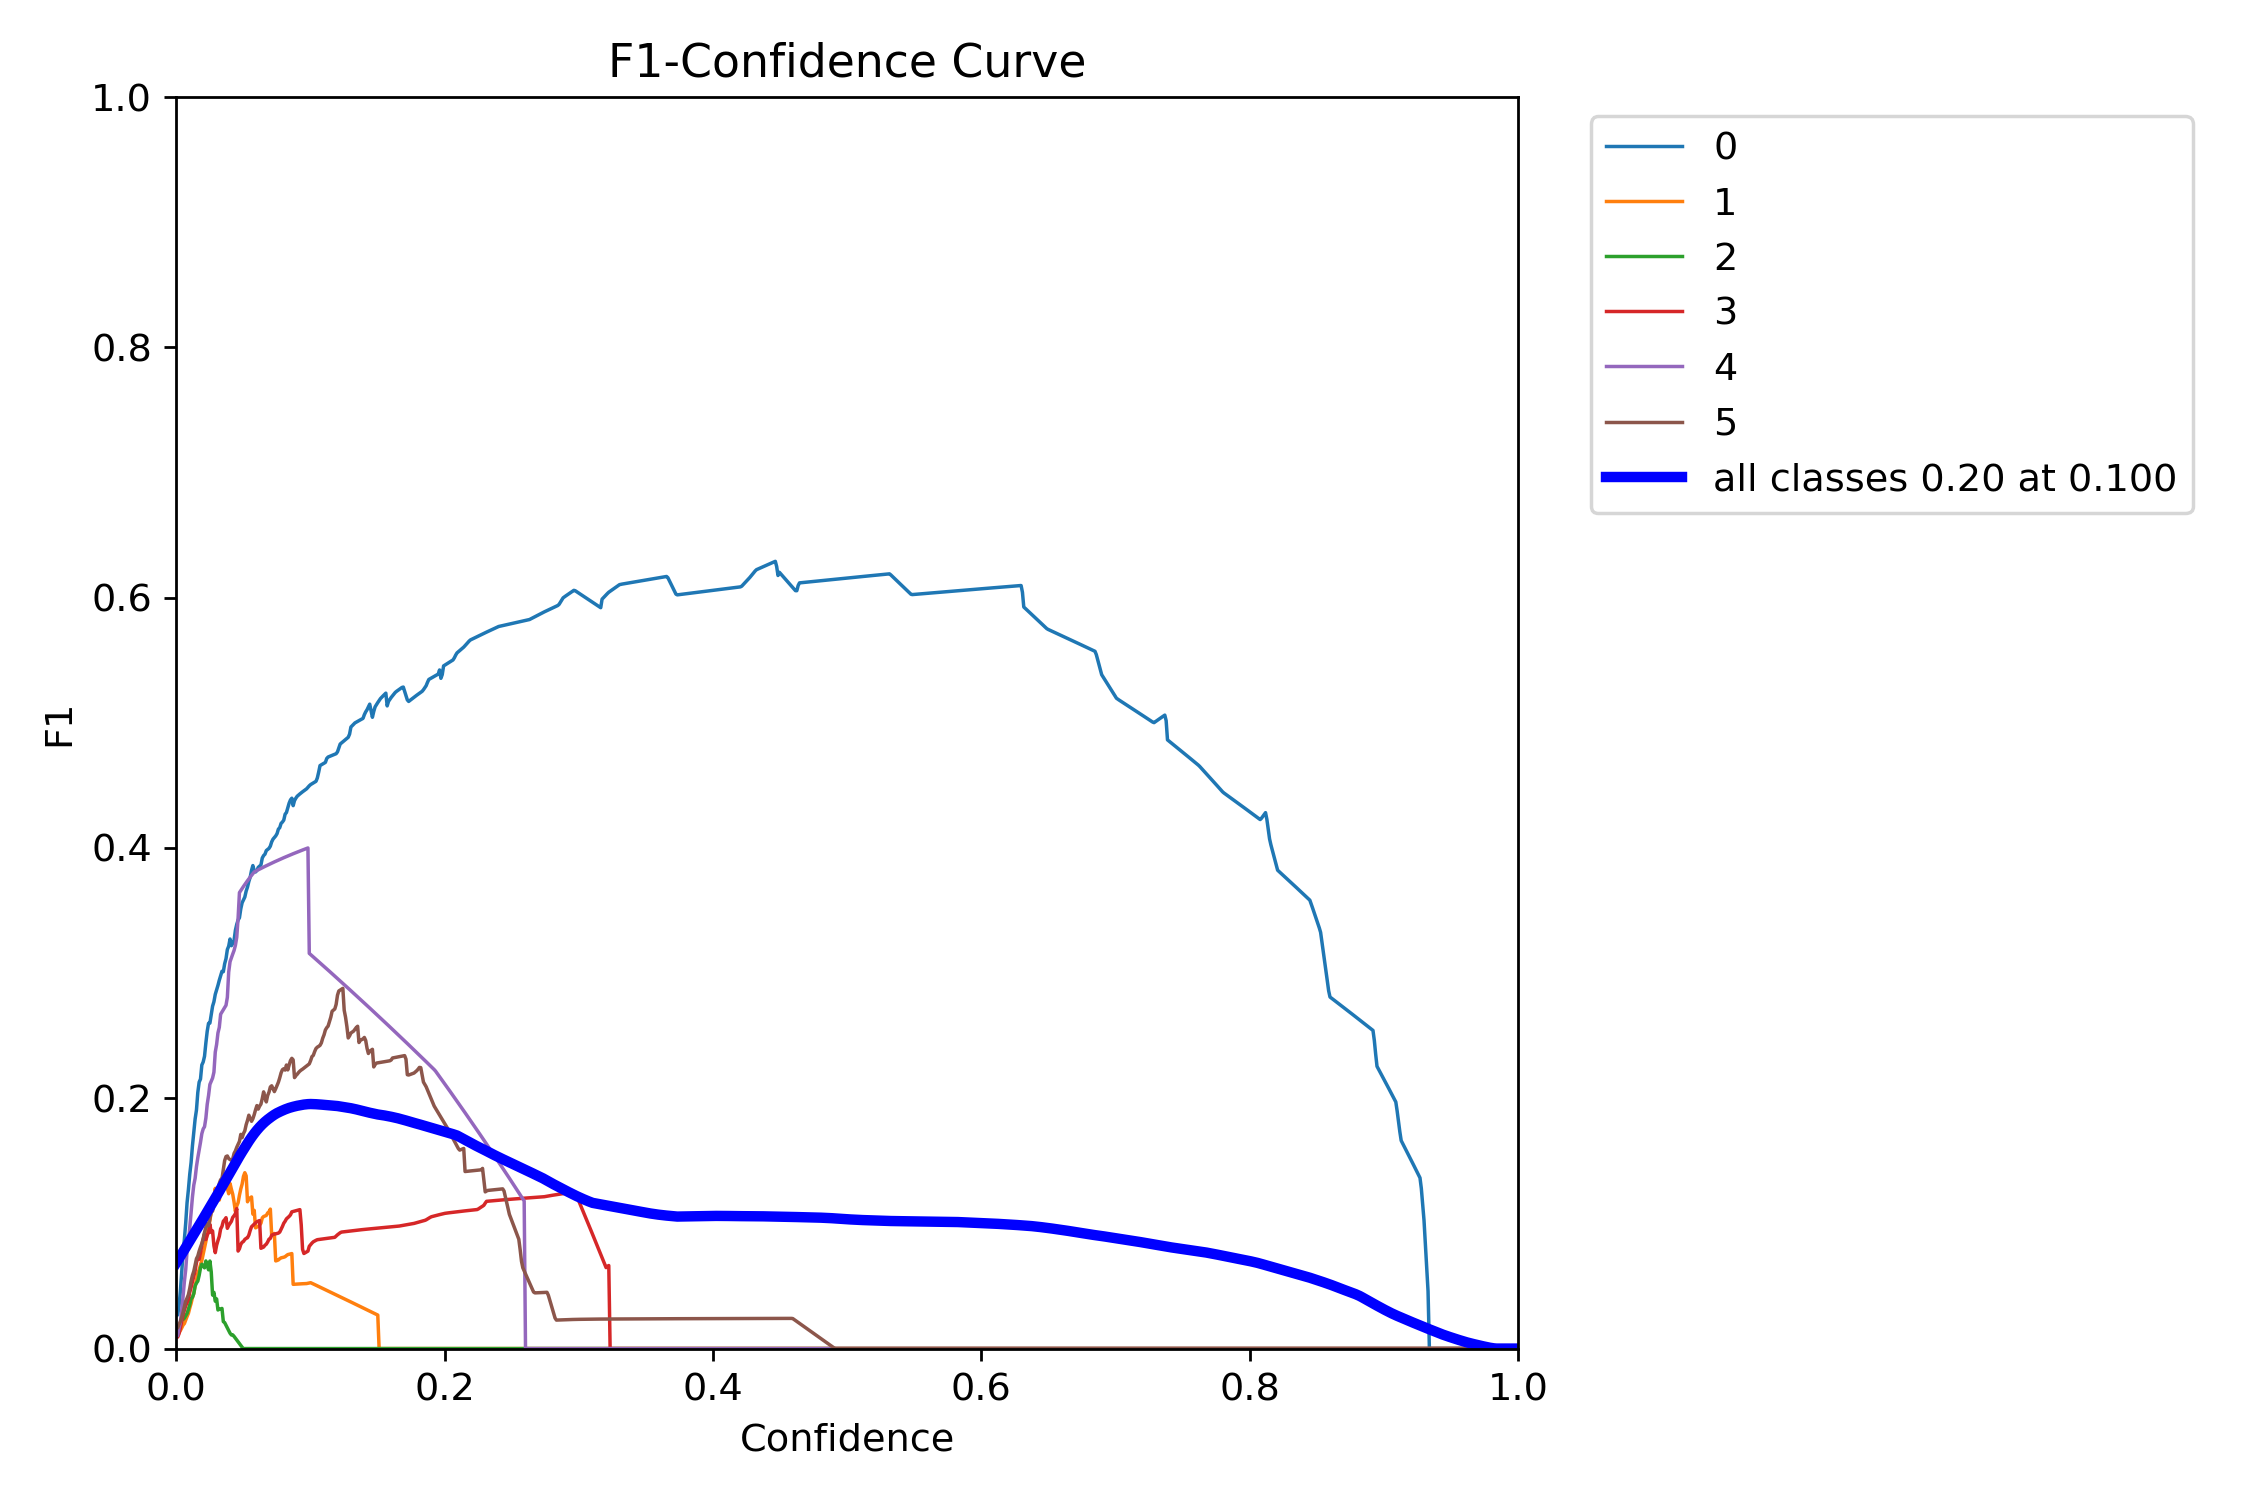

In [30]:
print("Displaying F1 Curve...")
display(Image(filename=r'C:\Users\Zione\runs\detect\val\BoxF1_curve.png'))

#### Precision-Recall Curve 


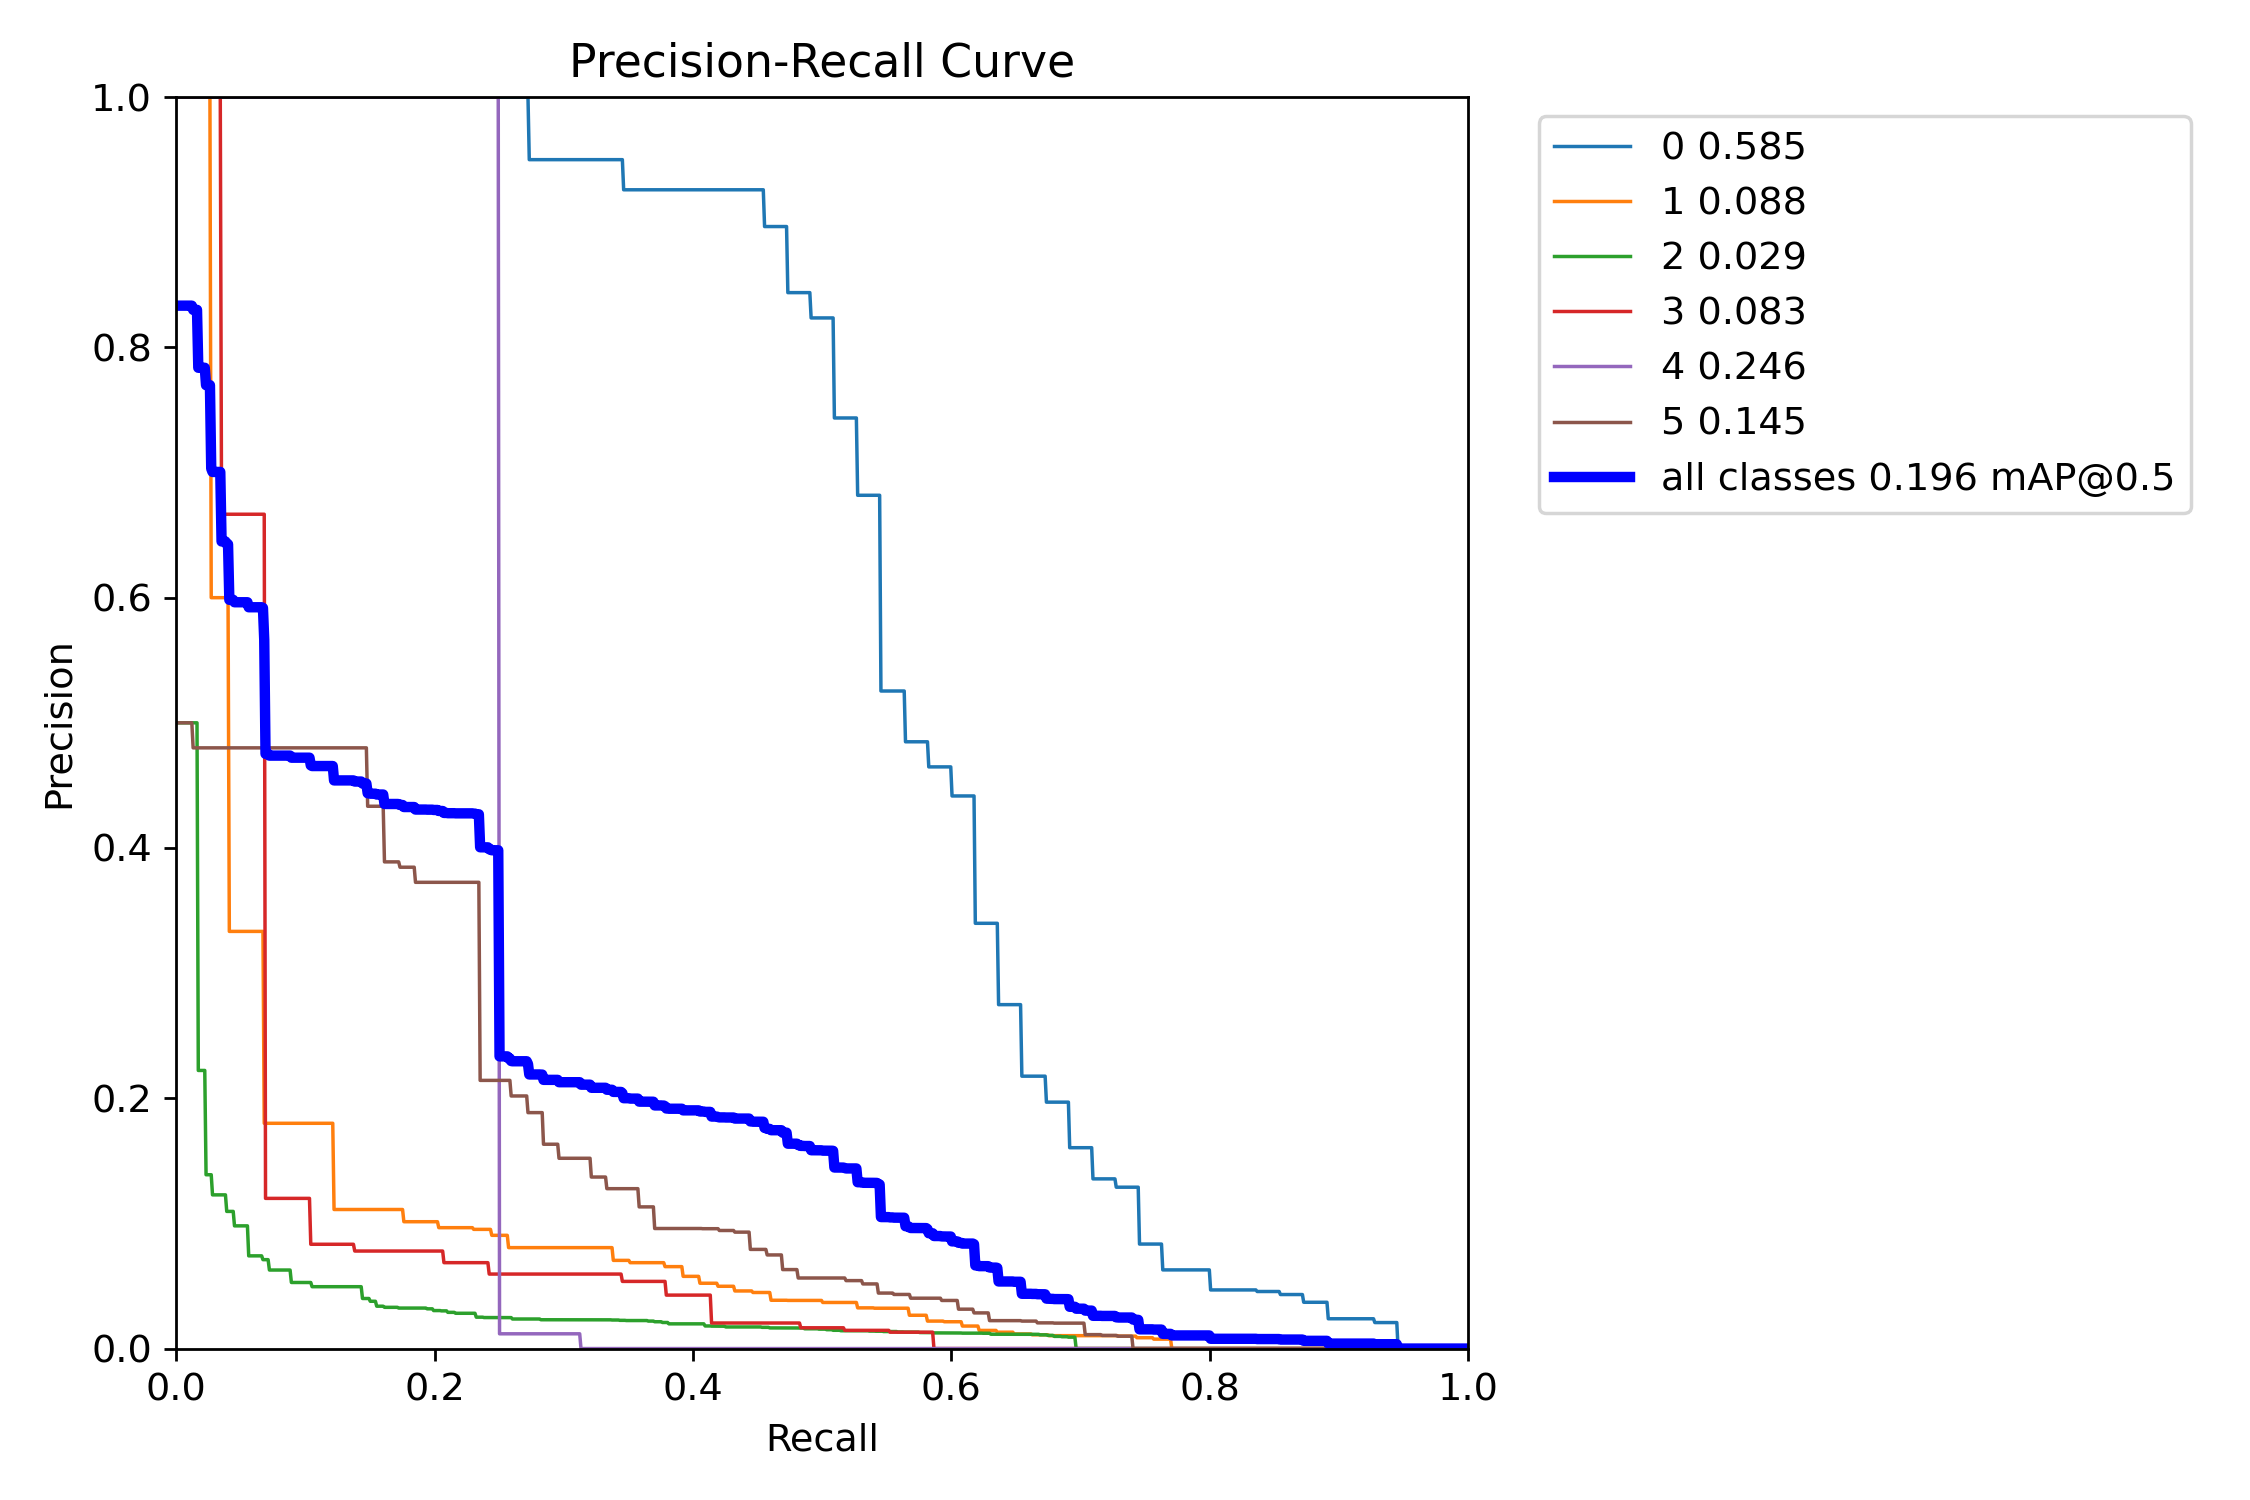

In [33]:
#Precision Curve Analysis

display(Image(filename=r'C:\Users\Zione\runs\detect\val\BoxPR_curve.png'))

#### Precision-Recall Curve Analysis
The Precision-Recall (PR) curve was used to evaluate the relationship between precision and recall across different solar panel classes.
The graph shows how the YOLOv8 model balances accurate detections and missed detections during validation.
Higher precision values indicate more reliable predictions, while higher recall values represent the model's ability to detect more solar panels.

### LOADING TRAINED MODEL

In [36]:
model = YOLO(r'C:\Users\Zione\runs\detect\train\weights\best.pt')

### SINGLE IMAGE PREDICTION / TESTING

##### Solar Panel Detection on Test Image

The trained model is tested on a new unseen rooftop image to evaluate its solar detection capability.

The system predicts:
- solar panel locations
- confidence levels
- object boundaries

In [37]:
results = model.predict(
    source='solar_testing_image.jpg',
    save=True,
    conf=0.25
)

print("Predictions are completed successfully")


image 1/1 c:\Users\Zione\Downloads\solar_panel_detection_project\solar_testing_image.jpg: 480x640 1 0, 198.8ms
Speed: 7.8ms preprocess, 198.8ms inference, 6.7ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\Zione\runs\detect\predict
Predictions are completed successfully


#### Detection Output


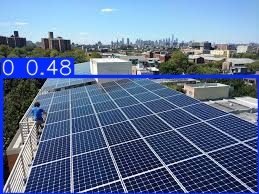

In [38]:

#DISPLAY PREDICTION
#Path to saved prediction image
predicted_path = os.path.join(
    results[0].save_dir,
    'solar_testing_image.jpg'
)
#Display prediction
display(Image(filename=predicted_path))

### Model Evaluation & Analysis


# Model Evaluation

After training the YOLOv8 model, I evaluated its ability to detect solar panels on validation and unseen images.

The model generated:
- bounding boxes
- confidence scores
- localization predictions

The evaluation process helps measure how accurately the system identifies solar panels across different environments and image conditions.

In [39]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.48  Python-3.12.4 torch-2.11.0+cpu CPU (Intel Core i7-7600U 2.80GHz)
val: Fast image access  (ping: 0.10.0 ms, read: 269.3111.4 MB/s, size: 75.7 KB)
val: Scanning C:\Users\Zione\Downloads\solar_panel_detection_project\solar-panel-1\valid\labels.cache... 137 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 137/137  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.5s/it 40.8s5.0ss
                   all        137        436      0.502      0.192      0.199       0.13
                     0         36         55      0.645        0.6      0.614       0.48
                     1         20         74      0.364      0.016        0.1     0.0422
                     2         38        181          1          0     0.0285    0.00779
                     3         15         29      0.314      0.138      0.148     0.0628
                     4         12         16      0.423      0.188      0.188      0

#### Confidence Score Interpretation
The confidence score represents how certain the YOLOv8 model is  about each detected solar panel objects.

In [40]:
#Extracting Confidence scores
for result in results:
    boxes = result.boxes

    for box in boxes:
        confidence = float(box.conf[0])

        print(f"Detected Solar Panel Confidence: {confidence:.2f}")

Detected Solar Panel Confidence: 0.48


#### Detection Count Analysis
I counted the detection solar panels to estimate the number of instalallations present in the Image. This shows that the model is not only able to detect solar panels, but can also support simple analysis tasks that could be improved further in future developments. 

In [42]:
#count detected solar panel 
for result in results:
    total_detection = len(result.boxes)

    print(f"Total Solar Panels Detected: {total_detection}")

Total Solar Panels Detected: 1


### MULTIPLE IMAGE TESTING

After getting successful predictions on a single image, I wanted to push the model further by testing it on multiple solar panel images with different rooftop conditions and viewing angles.

This stage helped me better understand:
- how consistent the model predictions were
- how confidence scores changed across images
- how well the model generalized to unseen data

The goal here was not just to get predictions, but to evaluate the practical reliability of the detection system

In [43]:

test_images = [
    'solarPv_image1.jpg',
    'solarPv_image2.jpg',
    'solarPv_image3.jpg'
]

for img in test_images:
    results = model.predict(source=img, save=True, conf=0.25)


image 1/1 c:\Users\Zione\Downloads\solar_panel_detection_project\solarPv_image1.jpg: 352x640 1 0, 266.2ms
Speed: 14.2ms preprocess, 266.2ms inference, 4.1ms postprocess per image at shape (1, 3, 352, 640)
Results saved to C:\Users\Zione\runs\detect\predict

image 1/1 c:\Users\Zione\Downloads\solar_panel_detection_project\solarPv_image2.jpg: 480x640 1 0, 229.4ms
Speed: 7.0ms preprocess, 229.4ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\Zione\runs\detect\predict

image 1/1 c:\Users\Zione\Downloads\solar_panel_detection_project\solarPv_image3.jpg: 480x640 1 0, 244.3ms
Speed: 7.0ms preprocess, 244.3ms inference, 5.2ms postprocess per image at shape (1, 3, 480, 640)
Results saved to C:\Users\Zione\runs\detect\predict


#### Displaying multiple testing images

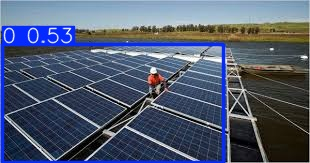

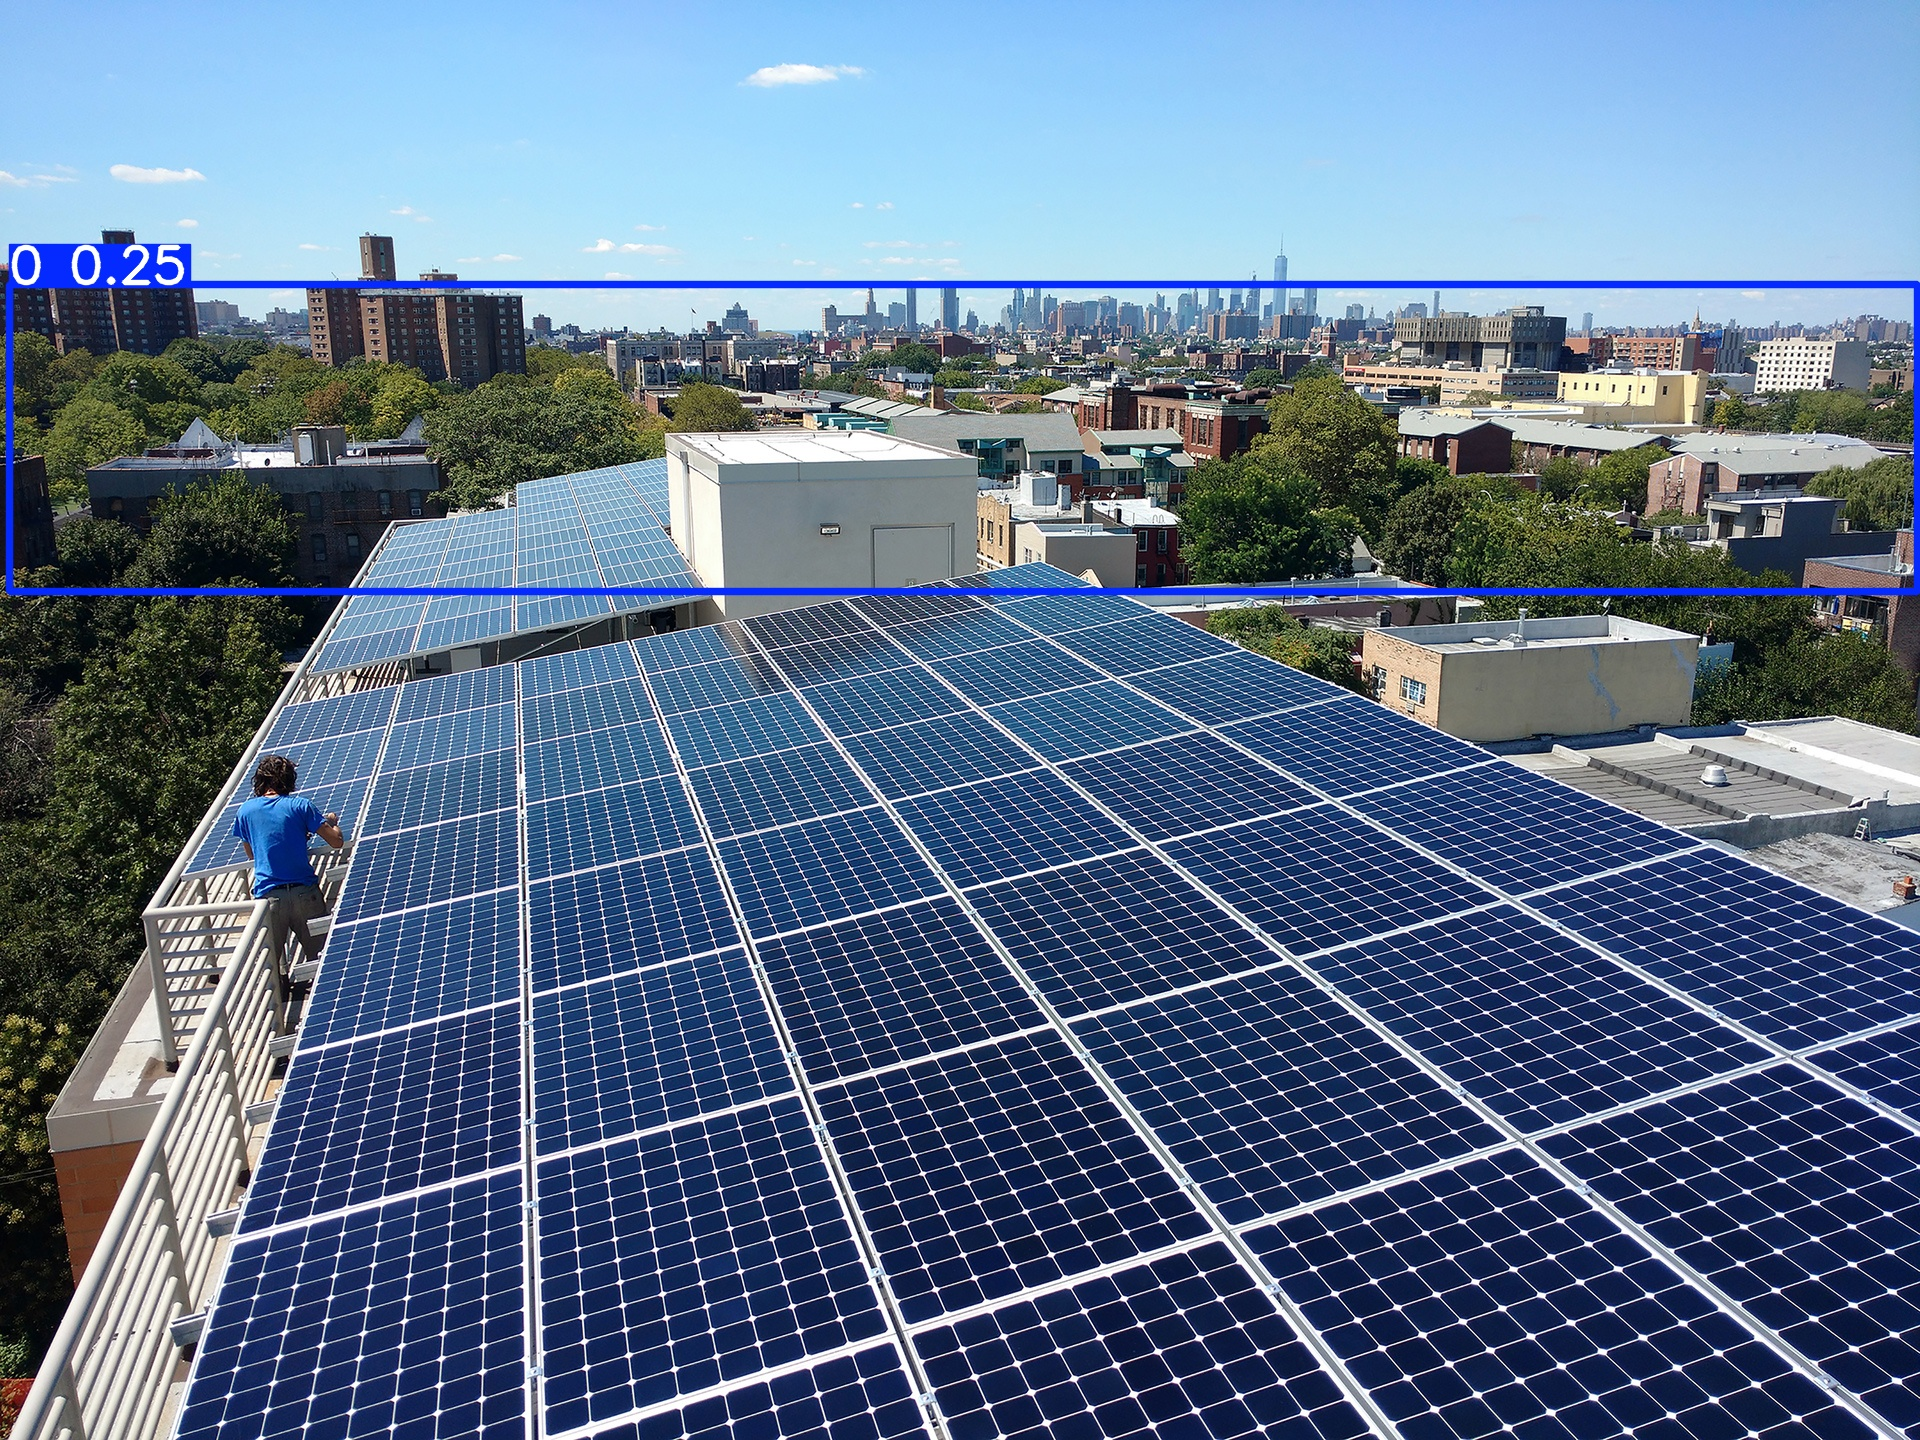

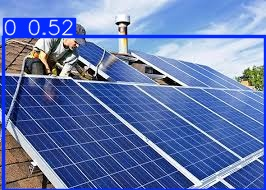

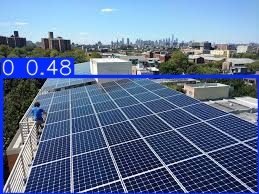

In [48]:
prediction_folder = r'C:\Users\Zione\runs\detect\predict'

for file in os.listdir(prediction_folder):
    display(Image(filename=os.path.join(prediction_folder, file)))